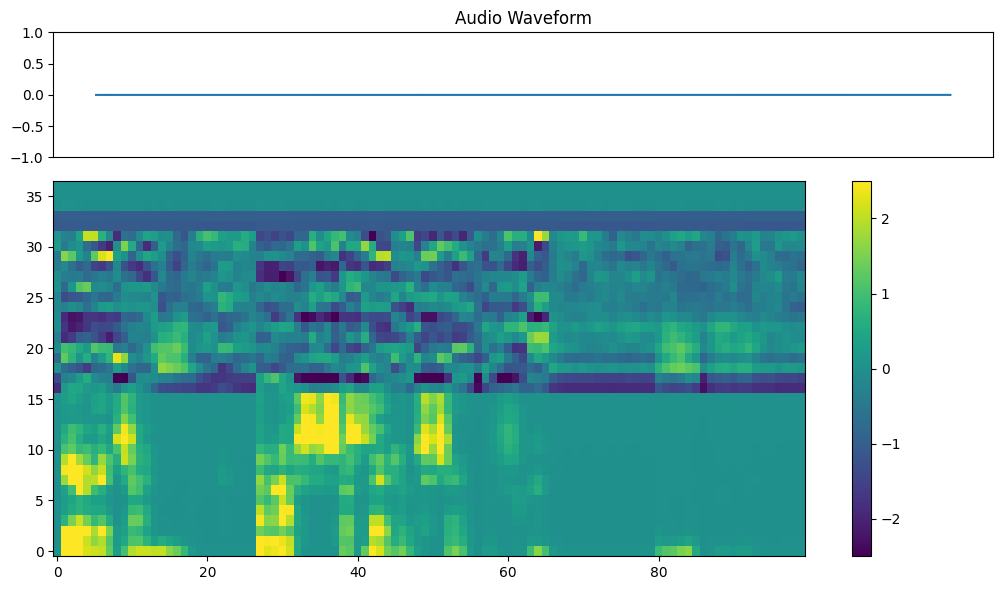

KeyboardInterrupt: 

In [1]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
import matplotlib.pyplot as plt
import sounddevice as sd
from IPython.display import clear_output
from utils.audio_processing.audio_features_extractor import AudioFeaturesExtractor
import time

# Global variables
sample_rate = 16000
fps = 30
chunk_size = int(sample_rate / fps)
context_frames = 100
audio_buffer = []
is_recording = False
stream = None
animation = None

# Create feature extractor
device = torch.device("cuda" if torch.cuda.is_available() else 
                     "mps" if torch.backends.mps.is_available() else 
                     "cpu")
feature_extractor = AudioFeaturesExtractor(
    sample_rate=sample_rate,
    context_frames=context_frames,
    device=device,
    normalization_file="dataset/genea2023_dataset/trn/main-agent/consolidated_meta.pkl"
)

def initialize_extractor():
    """Initialize the audio feature extractor"""
    from utils.audio_processing.audio_features_extractor import AudioFeaturesExtractor
    global feature_extractor
    
    feature_extractor = AudioFeaturesExtractor(
        sample_rate=sample_rate,
        context_frames=context_frames,
        device=device
    )
    print(f"Feature extractor initialized on device: {device}")

def audio_callback(indata, frames, time_info, status):
    """Process incoming audio data"""
    # if status:
    #     print(f"Audio callback status: {status}")
    
    # Convert to torch tensor
    audio_chunk = torch.from_numpy(indata[:, 0].copy()).reshape(1, -1).float()
    
    # Process the audio chunk
    if feature_extractor:
        feature_extractor.process_chunk(audio_chunk)

def update_plot():
    # Get the latest features
    features = feature_extractor.get_concatenated_features()
    if features is None:
        return
        
    # Plot waveform in top subplot
    # Set up figure for visualization
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), 
                             gridspec_kw={'height_ratios': [1, 3]})

    axes[0].plot(feature_extractor.buffer[0].cpu().numpy())
    axes[0].set_title('Audio Waveform')
    axes[0].set_ylim(-1, 1)
    axes[0].set_xticks([])
    
    # Plot features as heatmap in bottom subplot
    features_np = features.cpu().numpy().T
    im = axes[1].imshow(features_np, aspect='auto', cmap='viridis',
                       interpolation='nearest', origin='lower', vmin=-2.5, vmax=2.5)
    
    # Add colorbar
    plt.colorbar(im, ax=axes[1])
    
    fig.tight_layout()
    plt.show()

def start_recording():
    """Start recording audio and visualizing features"""
    global stream, animation, is_recording
    
    # Start audio stream
    stream = sd.InputStream(
        callback=audio_callback,
        samplerate=sample_rate,
        channels=1,
        blocksize=chunk_size
    )
    stream.start()
    
    is_recording = True

def stop_recording():
    """Stop recording and release resources"""
    global stream, is_recording
    
    if stream:
        stream.stop()
        stream.close()
        stream = None
    
    is_recording = False
    print("Recording stopped")


start_recording()

while True:
    update_plot()
    time.sleep(1 / fps)  # Control the update rate